In [32]:
import os
import numpy as np
import tensorflow as tf
import cv2
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Constants
IMAGE_SIZE = (128, 32)
BATCH_SIZE = 64
EPOCHS = 50
PADDING_TOKEN = 99
DATA_INPUT_PATH = "C:/Data Set/IAM 2/"

images_path = []
labels = []

# Load dataset
def preprocess_dataset():
    characters = set()
    max_len = 0
    with open(os.path.join(DATA_INPUT_PATH, 'iam_words', 'words.txt'), 'r') as file:
        for line in file:
            if line.startswith('#') or not line.strip():
                continue
            
            parts = line.strip().split()
            word_id = parts[0]
            first_folder = word_id.split("-")[0]
            second_folder = first_folder + '-' + word_id.split("-")[1]
            image_filename = f"{word_id}.png"
            image_path = os.path.join(DATA_INPUT_PATH, 'iam_words', 'words', first_folder, second_folder, image_filename)

            if os.path.isfile(image_path) and os.path.getsize(image_path):
                images_path.append(image_path)
                label = parts[-1].strip()
                characters.update(label)
                max_len = max(max_len, len(label))
                labels.append(label)

    characters = sorted(list(characters))
    char_to_num = tf.keras.layers.StringLookup(vocabulary=characters, mask_token=None)
    num_to_char = tf.keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True)
    return characters, char_to_num, num_to_char, max_len

characters, char_to_num, num_to_char, max_len = preprocess_dataset()

# Image Preprocessing
def preprocess_image(image_path, img_size):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Denoising using Bilateral Filtering
    image = cv2.bilateralFilter(image, 9, 75, 75)
    
    # Adaptive Histogram Equalization (CLAHE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    image = clahe.apply(image)
    
    # Adaptive Thresholding
    image = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    
    # Morphological Processing (Closing + Opening)
    kernel = np.ones((2,2), np.uint8)
    image = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
    image = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
    
    # Sharpen Image
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    image = cv2.filter2D(image, -1, sharpen_kernel)
    
    # Normalize and Resize
    image = image.astype(np.float32) / 255.0
    image = cv2.resize(image, img_size)
    
    return np.expand_dims(image, axis=-1)  # Add channel dimension

def vectorize_label(label):
    label = char_to_num(tf.strings.unicode_split(label, input_encoding="UTF-8"))
    return tf.pad(label, [[0, max_len - tf.shape(label)[0]]], constant_values=PADDING_TOKEN)

def process_images_labels(image_path, label):
    return {"image": preprocess_image(image_path, IMAGE_SIZE), "label": vectorize_label(label)}

def prepare_dataset(image_paths, labels):
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(lambda img, lbl: process_images_labels(img, lbl), num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.batch(BATCH_SIZE).cache().prefetch(tf.data.AUTOTUNE)

def split_dataset():
    train_images, test_images, train_labels, test_labels = train_test_split(images_path, labels, test_size=0.2, random_state=42)
    val_images, test_images, val_labels, test_labels = train_test_split(test_images, test_labels, test_size=0.5, random_state=42)
    return prepare_dataset(train_images, train_labels), prepare_dataset(val_images, val_labels), prepare_dataset(test_images, test_labels)

train_set, val_set, test_set = split_dataset()

# CTC Loss Layer
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost
    
    def call(self, y_true, y_pred):
        batch_len = tf.shape(y_true)[0]
        input_length = tf.fill([batch_len, 1], tf.shape(y_pred)[1])
        label_length = tf.fill([batch_len, 1], tf.shape(y_true)[1])
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)
        return y_pred

# Model Definition
def build_model():
    input_img = tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1), name="image")
    labels = tf.keras.layers.Input(name="label", shape=(None,))
    
    x = tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same")(input_img)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    
    x = tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    
    x = tf.keras.layers.Reshape(((IMAGE_SIZE[0] // 4), (IMAGE_SIZE[1] // 4) * 128))(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.3))(x)
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.3))(x)
    
    x = tf.keras.layers.Dense(len(char_to_num.get_vocabulary()) + 2, activation="softmax", name="dense2")(x)
    output = CTCLayer(name="ctc_loss")(labels, x)
    
    model = tf.keras.models.Model(inputs=[input_img, labels], outputs=output)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005))
    return model

model = build_model()


error: in user code:

    File "C:\Users\vaibh\AppData\Local\Temp\ipykernel_2796\2894321048.py", line 86, in None  *
        lambda img, lbl: process_images_labels(img, lbl)
    File "C:\Users\vaibh\AppData\Local\Temp\ipykernel_2796\2894321048.py", line 82, in process_images_labels  *
        return {"image": preprocess_image(image_path, IMAGE_SIZE), "label": vectorize_label(label)}
    File "C:\Users\vaibh\AppData\Local\Temp\ipykernel_2796\2894321048.py", line 50, in preprocess_image  *
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    error: OpenCV(4.10.0) :-1: error: (-5:Bad argument) in function 'imread'
    > Overload resolution failed:
    >  - Expected 'filename' to be a str or path-like object
    >  - Expected 'filename' to be a str or path-like object
    >  - Expected 'filename' to be a str or path-like object
    


In [21]:
import os
import tensorflow as tf
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Path to the trained model
MODEL_PATH = "C:/Data Set/Trained model/MODEL_NAME.keras"

# Load the trained model
model = load_model(MODEL_PATH)

# Define image preprocessing function (FIXED)
def preprocess_image(image_path, img_size=(128, 32)):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
    image = cv2.resize(image, (img_size[1], img_size[0]), interpolation=cv2.INTER_AREA)  # Ensure (128, 32)
    image = image.astype(np.float32) / 255.0  # Normalize pixel values
    image = np.expand_dims(image, axis=-1)  # Add channel dimension (H, W, 1)
    image = np.expand_dims(image, axis=0)   # Add batch dimension (1, H, W, 1)
    return image

# Define function to decode predictions
def decode_prediction(pred, num_to_char, max_len):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][:, :max_len]

    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    return output_text

# Load the num_to_char mapping (same as training)
characters = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
num_to_char = tf.keras.layers.StringLookup(vocabulary=list(characters), mask_token=None, invert=True)
max_len = 32  # Update this based on your training max sequence length

# Path to the external image
external_image_path = "C:/Users/vaibh/Downloads/train14.jpg"

# Preprocess the external image
processed_image = preprocess_image(external_image_path)

# Make a prediction
predicted_output = model.predict(processed_image)

# Decode the predicted text
predicted_text = decode_prediction(predicted_output, num_to_char, max_len)

print("Predicted Text:", predicted_text[0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step
Predicted Text: o[UNK][UNK]Y9o9


In [5]:
# -*- coding: utf-8 -*-
"""
Created on Thu Mar 27 10:22:46 2025

@author: admin
"""

import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

IMAGE_SIZE = (128, 32)
BATCH_SIZE = 64
EPOCHS = 1
PADDING_TOKEN = 99
# DATA_INPUT_PATH = "/kaggle/input/withexperimental"

DATA_INPUT_PATH = "C:/Data Set/IAM 2/iam_words/"

images_path = []
labels = []

def preprocess_dataset():
    characters = set()
    max_len = 0
    with open(os.path.join(DATA_INPUT_PATH, 'iam_words', 'words.txt'), 'r') as file:
        lines = file.readlines()

        for line_number, line in enumerate(lines):
            # Skip comments and empty lines
            if line.startswith('#') or line.strip() == '':
                continue

            # Split the line and extract information
            parts = line.strip().split()

            # Continue with the rest of the code
            word_id = parts[0]

            first_folder = word_id.split("-")[0]
            second_folder = first_folder + '-' + word_id.split("-")[1]

            # Construct the image filename
            image_filename = f"{word_id}.png"
            image_path = os.path.join(
                DATA_INPUT_PATH, 'iam_words', 'words', first_folder, second_folder, image_filename)

            # Check if the image file exists
            if os.path.isfile(image_path) and os.path.getsize(image_path):

                images_path.append(image_path)

                # Extract labels
                label = parts[-1].strip()
                for char in label:
                    characters.add(char)

                max_len = max(max_len, len(label))
                labels.append(label)

    characters = sorted(list(characters))

    print('characters: ', characters)
    print('max_len: ', max_len)
    # Mapping characters to integers.
    char_to_num = tf.keras.layers.StringLookup(
        vocabulary=list(characters), mask_token=None)

    # Mapping integers back to original characters.
    num_to_char = tf.keras.layers.StringLookup(
        vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True
    )
    return characters, char_to_num, num_to_char, max_len
    
characters, char_to_num, num_to_char, max_len = preprocess_dataset()


def distortion_free_resize(image, img_size):
    w, h = img_size
    image = tf.image.resize(image, size=(h, w), preserve_aspect_ratio=True)

    # Check tha amount of padding needed to be done.
    pad_height = h - tf.shape(image)[0]
    pad_width = w - tf.shape(image)[1]

    # Only necessary if you want to do same amount of padding on both sides.
    if pad_height % 2 != 0:
        height = pad_height // 2
        pad_height_top = height + 1
        pad_height_bottom = height
    else:
        pad_height_top = pad_height_bottom = pad_height // 2

    if pad_width % 2 != 0:
        width = pad_width // 2
        pad_width_left = width + 1
        pad_width_right = width
    else:
        pad_width_left = pad_width_right = pad_width // 2

    image = tf.pad(
        image,
        paddings=[
            [pad_height_top, pad_height_bottom],
            [pad_width_left, pad_width_right],
            [0, 0],
        ],
    )

    image = tf.transpose(image, perm=[1, 0, 2])
    image = tf.image.flip_left_right(image)
    return image

def preprocess_image(image_path, img_size):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, 1)
    image = distortion_free_resize(image, img_size)
    image = tf.cast(image, tf.float32) / 255.0
    return image

def vectorize_label(label):
    label = char_to_num(tf.strings.unicode_split(
        label, input_encoding="UTF-8"))
    length = tf.shape(label)[0]
    pad_amount = max_len - length
    label = tf.pad(label, paddings=[[0, pad_amount]],
                   constant_values=PADDING_TOKEN)
    return label

def process_images_labels(image_path, label):
    image = preprocess_image(image_path, IMAGE_SIZE)
    label = vectorize_label(label)
    return {"image": image, "label": label}

def prepare_dataset(image_paths, labels):
    AUTOTUNE = tf.data.AUTOTUNE
    print('len(image_paths): ', len(image_paths))
    print('len(labels): ', len(labels))
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels)).map(
        process_images_labels, num_parallel_calls=AUTOTUNE
    )
    return dataset.batch(BATCH_SIZE).cache().prefetch(AUTOTUNE)

def split_dataset():
    # Split the data into training, validation, and test sets using train_test_split
    train_images, test_images, train_labels, test_labels = train_test_split(
        images_path, labels, test_size=0.2, random_state=42
    )

    # Further split the test set into validation and final test sets
    val_images, test_images, val_labels, test_labels = train_test_split(
        test_images, test_labels, test_size=0.5, random_state=42
    )

    train_set = prepare_dataset(train_images, train_labels)
    val_set = prepare_dataset(val_images, val_labels)
    test_set = prepare_dataset(test_images, test_labels)
    
    return train_set, val_set, test_set

train_set, val_set, test_set = split_dataset()

class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, name=None):
        super().__init__(name=name)
        self.loss_fn = tf.keras.backend.ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
        input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
        label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

        input_length = input_length * \
            tf.ones(shape=(batch_len, 1), dtype="int64")
        label_length = label_length * \
            tf.ones(shape=(batch_len, 1), dtype="int64")
        loss = self.loss_fn(y_true, y_pred, input_length, label_length)
        self.add_loss(loss)

        # At test time, just return the computed predictions.
        return y_pred
    

def build_model():
    input_img = tf.keras.Input(
        shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1), name="image")
    labels = tf.keras.layers.Input(name="label", shape=(None,))

    x = tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
    )(input_img)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    x = tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        kernel_initializer="he_normal",
        padding="same",
    )(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)
    new_shape = ((IMAGE_SIZE[0] // 4), (IMAGE_SIZE[1] // 4) * 64)
    x = tf.keras.layers.Reshape(target_shape=new_shape)(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.25)
    )(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True, dropout=0.25)
    )(x)
    x = tf.keras.layers.Dense(
        len(char_to_num.get_vocabulary()) + 2, activation="softmax", name="dense2"
    )(x)
    output = CTCLayer(name="ctc_loss")(labels, x)
    model = tf.keras.models.Model(
        inputs=[input_img, labels], outputs=output
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
    model.summary()
    return model
    
model = build_model()


class EditDistanceCallback(tf.keras.callbacks.Callback):
    def __init__(self, pred_model, max_len, validation_images, validation_labels):
        super().__init__()
        self.prediction_model = pred_model
        self.max_len = max_len
        self.validation_images = validation_images
        self.validation_labels = validation_labels

    def calculate_edit_distance(self, labels, predictions, max_len):
        # Get a single batch and convert its labels to sparse tensors.
        saprse_labels = tf.cast(tf.sparse.from_dense(labels), dtype=tf.int64)

        # Make predictions and convert them to sparse tensors.
        input_len = np.ones(predictions.shape[0]) * predictions.shape[1]
        predictions_decoded = tf.keras.backend.ctc_decode(
            predictions, input_length=input_len, greedy=True
        )[0][0][:, :max_len]
        sparse_predictions = tf.cast(
            tf.sparse.from_dense(predictions_decoded), dtype=tf.int64
        )

        # Compute individual edit distances and average them out.
        edit_distances = tf.edit_distance(
            sparse_predictions, saprse_labels, normalize=False
        )
        return tf.reduce_mean(edit_distances)

    def on_epoch_end(self, epoch, logs=None):
        edit_distances = []

        for i in range(len(self.validation_images)):
            labels = self.validation_labels[i]
            predictions = self.prediction_model.predict(
                self.validation_images[i], verbose=0)
            edit_distances.append(self.calculate_edit_distance(
                labels, predictions, self.max_len).numpy())

        print(
            f"Mean edit distance for epoch {epoch + 1}: {np.mean(edit_distances):.4f}"
        )
        

def train_model():
    validation_images = []
    validation_labels = []

    for batch in val_set:
        validation_images.append(batch["image"])
        validation_labels.append(batch["label"])

    if not validation_images:
        raise ValueError("Validation dataset is empty! Check dataset loading.")

    prediction_model = tf.keras.models.Model(
    inputs=model.input[0],  # Ensure correct input
    outputs=model.get_layer(name="dense2").output
)

    
    edit_distance_callback = EditDistanceCallback(
        prediction_model, max_len, validation_images, validation_labels
    )
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )

    hist = model.fit(
        train_set,
        validation_data=val_set,
        epochs=EPOCHS,
        callbacks=[edit_distance_callback, early_stopping],
    )
    return hist, prediction_model
print("Model inputs:", model.input)
print("Model outputs:", model.get_layer(name="dense2").output)


history, prediction_model = train_model()


def visualize_train_history(history):
    plt.figure(figsize=(12, 4))

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.tight_layout()
    plt.show()

visualize_train_history(history)


def evaluate_model():
    accuracy = model.evaluate(test_set)
    print("Test Accuracy:", accuracy)

evaluate_model() 


MODEL_NAME = 'MODEL_NAME1'
MODEL_OUTPUT_PATH = 'C:/Data Set/Trained model/MODEL_NAME1.keras'
        
def save_model():
    """
    Save the trained HTR model.
    """
    os.makedirs(MODEL_OUTPUT_PATH, exist_ok=True)
    prediction_model.save(os.path.join(
        MODEL_OUTPUT_PATH, f'{MODEL_NAME}.keras'))
    
save_model()


def decode_batch_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    # Use greedy search. For complex tasks, you can use beam search.
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][
        :, :max_len
    ]

    # Iterate over the results and get back the text.
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    return output_text


#  Let's check results on some test samples.
for batch in test_set.take(2):
    batch_images = batch["image"]
    batch_labels = batch["label"]
    _, ax = plt.subplots(4, 4, figsize=(15, 8))

    preds = prediction_model.predict(batch_images)
    pred_texts = decode_batch_predictions(preds)

    for i in range(16):
        img = batch_images[i]
        img = tf.image.flip_left_right(img)
        img = tf.transpose(img, perm=[1, 0, 2])
        img = (img * 255.0).numpy().clip(0, 255).astype(np.uint8)
        img = img[:, :, 0]

        title = f"Prediction: {pred_texts[i]}"
        ax[i // 4, i % 4].imshow(img, cmap="gray")
        ax[i // 4, i % 4].set_title(title)
        ax[i // 4, i % 4].axis("off")

plt.show()




FileNotFoundError: [Errno 2] No such file or directory: 'C:/Data Set/IAM 2/iam_words/iam_words\\words.txt'

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 988ms/step


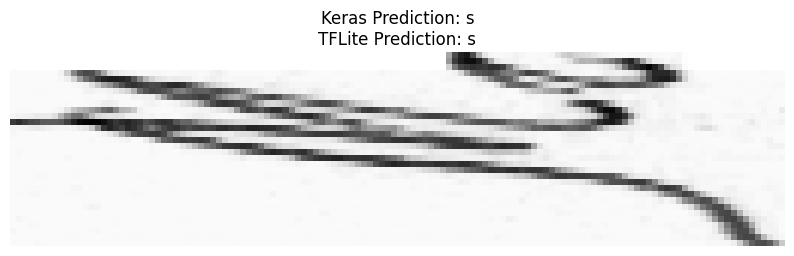

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# Assuming you have loaded your Keras and TFLite models
keras_model = tf.keras.models.load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your Keras model path
tflite_interpreter = tf.lite.Interpreter(model_path='C://Data Set//Trained model//MODEL_NAME.tflite') # Replace with your tflite model path
tflite_interpreter.allocate_tensors()

input_details = tflite_interpreter.get_input_details()
output_details = tflite_interpreter.get_output_details()

def decode_single_predictions(pred, is_tflite=False):
    if is_tflite:
        pred = pred[0] #TFLite output is in a list
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][:, :max_len]
    output_text = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        res = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        output_text.append(res)
    return output_text

# Function to perform inference with TFLite model
def tflite_predict(images):
    tflite_predictions = []
    for img in images:
        img = np.expand_dims(img, axis=0).astype(np.float32) #expand dims and convert to float32
        tflite_interpreter.set_tensor(input_details[0]['index'], img)
        tflite_interpreter.invoke()
        tflite_output = tflite_interpreter.get_tensor(output_details[0]['index'])
        tflite_predictions.append(tflite_output)
    return np.array(tflite_predictions)

# Custom test image loading
test_image_path = 'C://Data Set//IAM 2//iam_words//words//a06//a06-000//a06-000-00-00.png'  # Replace with your test image path
image_height = 128  # Replace with your model's image height
image_width = 32   # Replace with your model's image width

def load_single_test_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_image(img, channels=1, dtype=tf.float32)
    img = tf.image.resize(img, (image_height, image_width))
    img = tf.expand_dims(img, axis=0)  # Add batch dimension
    return img

test_image = load_single_test_image(test_image_path)

# Make predictions
keras_preds = keras_model.predict(test_image)
keras_pred_texts = decode_single_predictions(keras_preds)

tflite_preds = tflite_predict(test_image)
tflite_pred_texts = decode_single_predictions(tflite_preds, is_tflite=True)

# Display the image and predictions
img = test_image[0]  # Remove batch dimension
img = tf.image.flip_left_right(img)
img = tf.transpose(img, perm=[1, 0, 2])
img = (img * 255.0).numpy().clip(0, 255).astype(np.uint8)
img = img[:, :, 0]

plt.figure(figsize=(10, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Keras Prediction: {keras_pred_texts[0]}\nTFLite Prediction: {tflite_pred_texts[0]}")
plt.axis("off")
plt.show()

In [27]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Data Set/IAM 2/iam_words/words/a06/a06-000/a06-000-02-05.png'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:11:06,842: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: ChanceQObs, Confidence: 0.2075


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

2025-04-03 13:12:01,453: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: may, Confidence: 0.9914

Final Extracted Text:
1. Detected Text: may
    Confidence: 0.99 (High)
    Source: EasyOCR
----------------------------------------
Summary:
Total Results: 1
 - EasyOCR: 1
 - CRNN: 0


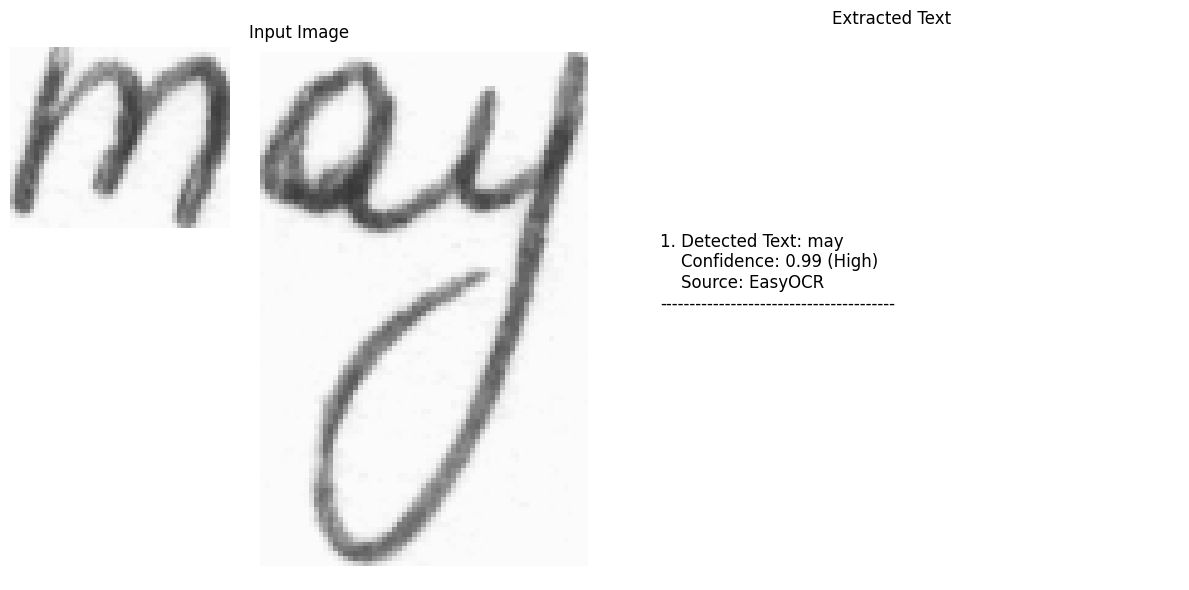

In [28]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Data Set/IAM 2/iam_words/words/a06/a06-000/a06-000-00-03.png'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

In [29]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Data Set/IAM 2/iam_words/words/a06/a06-000/a06-000-05-00.png'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:12:53,338: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Lloy, Confidence: 0.5046


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

2025-04-03 13:14:21,439: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: One, Confidence: 0.8869

Final Extracted Text:
1. Detected Text: one
    Confidence: 0.89 (High)
    Source: EasyOCR
----------------------------------------
Summary:
Total Results: 1
 - EasyOCR: 1
 - CRNN: 0


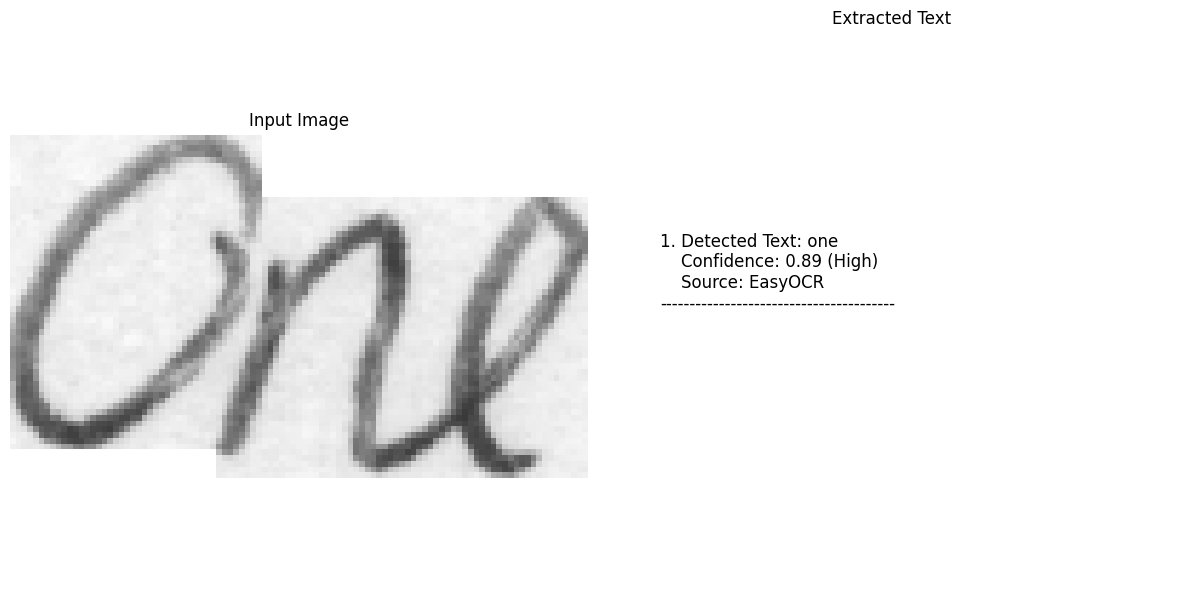

In [30]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Data Set/IAM 2/iam_words/words/b02/b02-045/b02-045-00-01.png'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

In [32]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = '"C:\Data Set\IAM 2\iam_words\words\b02\b02-045\b02-045-01-07.png'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:18:41,094: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


ValueError: Invalid input type. Supporting format = string(file path or url), bytes, numpy array

2025-04-03 13:19:06,217: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: which, Confidence: 0.8085

Final Extracted Text:
1. Detected Text: which
    Confidence: 0.81 (Medium)
    Source: EasyOCR
----------------------------------------
Summary:
Total Results: 1
 - EasyOCR: 1
 - CRNN: 0


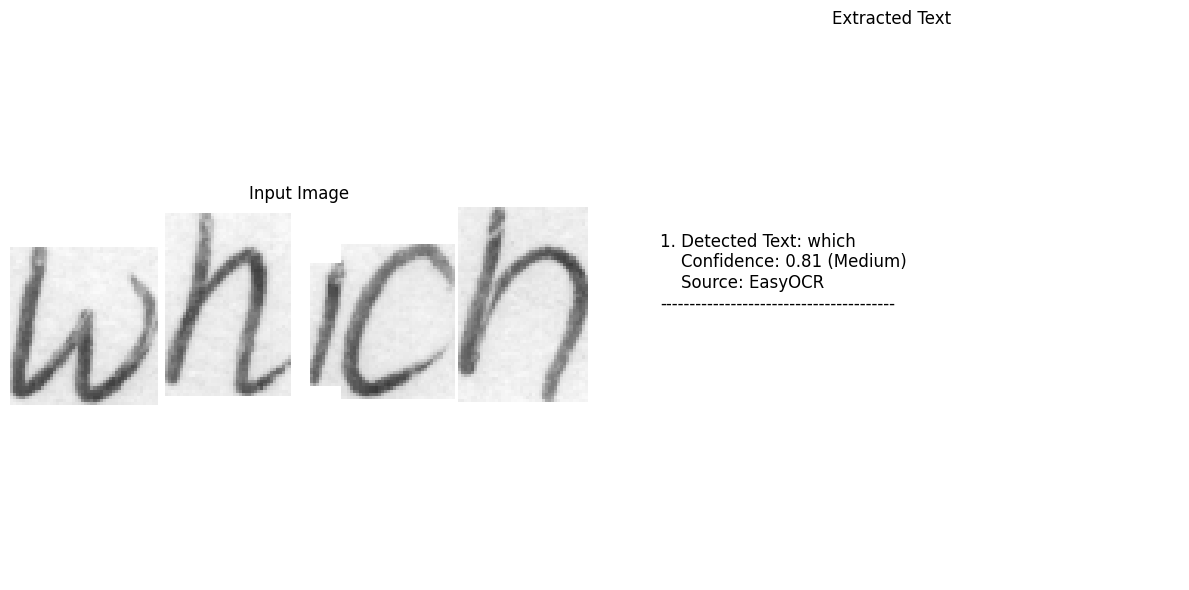

In [33]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Data Set/IAM 2/iam_words/words/b02/b02-045/b02-045-00-03.png'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:23:49,716: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Tony, Confidence: 0.9703

Final Extracted Text:
1. Detected Text: tony
    Confidence: 0.97 (High)
    Source: EasyOCR
----------------------------------------
Summary:
Total Results: 1
 - EasyOCR: 1
 - CRNN: 0


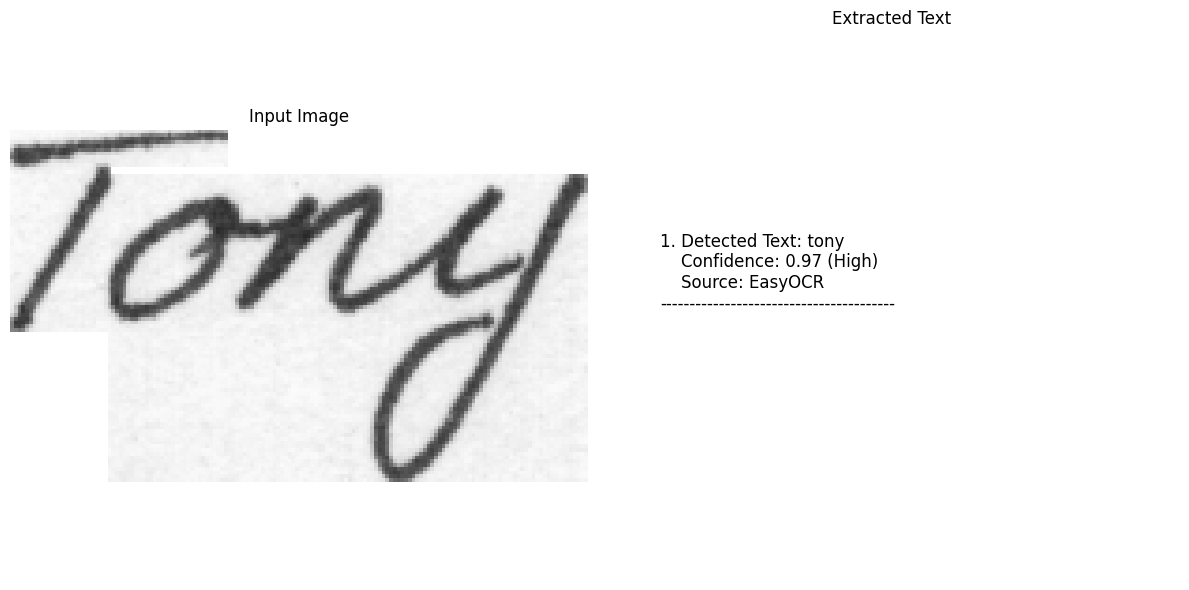

In [39]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Data Set/IAM 2/iam_words/words/c03/c03-000d/c03-000d-03-05.png'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:31:51,374: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Medial, Confidence: 0.7410
Detected: Text, Confidence: 0.9750
Detected: Extqaction, Confidence: 0.8258

Final Extracted Text:
1. Detected Text: medial
    Confidence: 0.74 (Medium)
    Source: EasyOCR
----------------------------------------
2. Detected Text: text
    Confidence: 0.97 (High)
    Source: EasyOCR
----------------------------------------
3. Detected Text: extqaction
    Confidence: 0.83 (Medium)
    Source: EasyOCR
----------------------------------------
Summary:
Total Results: 3
 - EasyOCR: 3
 - CRNN: 0


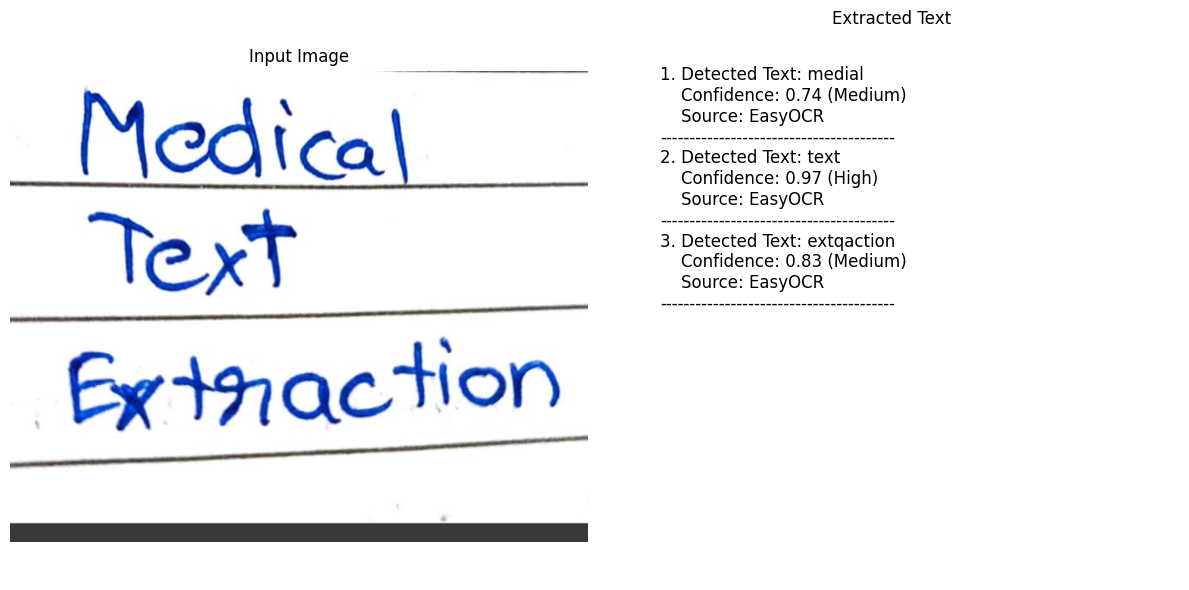

In [49]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/train14.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

In [50]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/train2.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:35:30,794: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Neural, Confidence: 0.9997
Detected: Net, Confidence: 0.9876
Detected: Convolutional, Confidence: 0.6284


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

In [53]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/tt1.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:41:30,165: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Aspixin, Confidence: 0.8683
Detected: Pay aceFamo|, Confidence: 0.5946


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

In [54]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/tt2.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:43:38,885: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Asp ixin, Confidence: 0.3905


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

2025-04-03 13:44:23,682: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: TANSKY, Confidence: 0.8544

Final Extracted Text:
1. Detected Text: tansky
    Confidence: 0.85 (High)
    Source: EasyOCR
----------------------------------------
Summary:
Total Results: 1
 - EasyOCR: 1
 - CRNN: 0


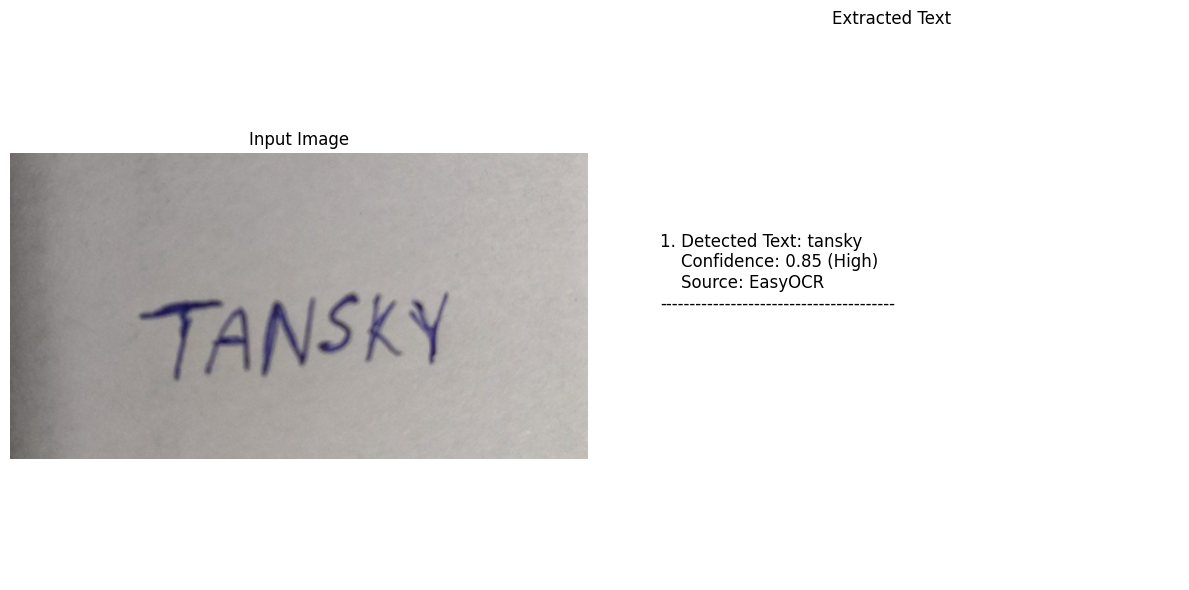

In [55]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/tt3.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

In [56]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/tt4.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:44:56,675: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: 5, Confidence: 0.8604
Detected: Aspirin, Confidence: 0.9605
Detected: Unani, Confidence: 0.9155
Detected: Do(on0, Confidence: 0.6823


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

In [57]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/tt5.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:47:13,453: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Hemeglobn Tes+, Confidence: 0.4943


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

In [58]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/sj1.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:48:48,560: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: not, Confidence: 0.9983
Detected: hold, Confidence: 0.7532
Detected: o0, Confidence: 0.5145


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

2025-04-03 13:49:42,603: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Ass, Confidence: 0.9172
Detected: ho, Confidence: 0.9990

Final Extracted Text:
1. Detected Text: ass
    Confidence: 0.92 (High)
    Source: EasyOCR
----------------------------------------
2. Detected Text: ho
    Confidence: 1.00 (High)
    Source: EasyOCR
----------------------------------------
Summary:
Total Results: 2
 - EasyOCR: 2
 - CRNN: 0


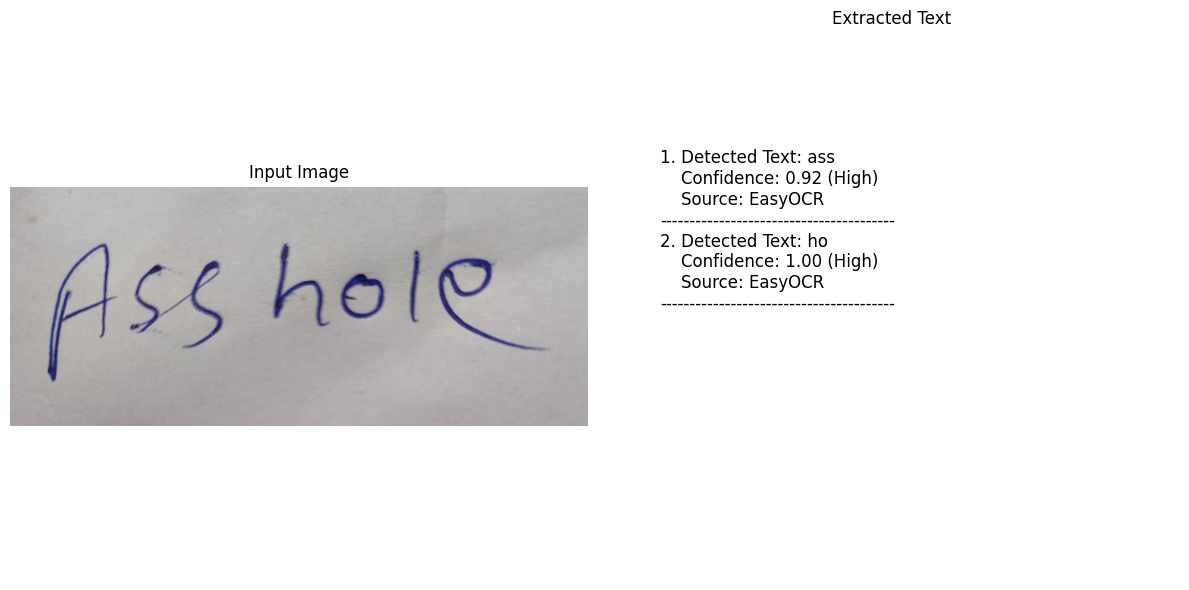

In [59]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/sj3.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

In [60]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/sj2.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:50:13,159: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Give, Confidence: 0.9998
Detected: mun, Confidence: 0.8291
Detected: 0, Confidence: 0.8904
Detected: Jun, Confidence: 0.5366


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

In [62]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/bj2.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 13:54:13,800: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Harzh perodz badhSoham, Confidence: 0.4266


ValueError: Input 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

In [3]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//tanmay model_Gem.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[char] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/prescription3.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-03 19:45:31,220: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: 2x, Confidence: 0.0710


ValueError: Input 0 of layer "functional_3" is incompatible with the layer: expected shape=(None, 128, 32, 1), found shape=(1, 28, 28)

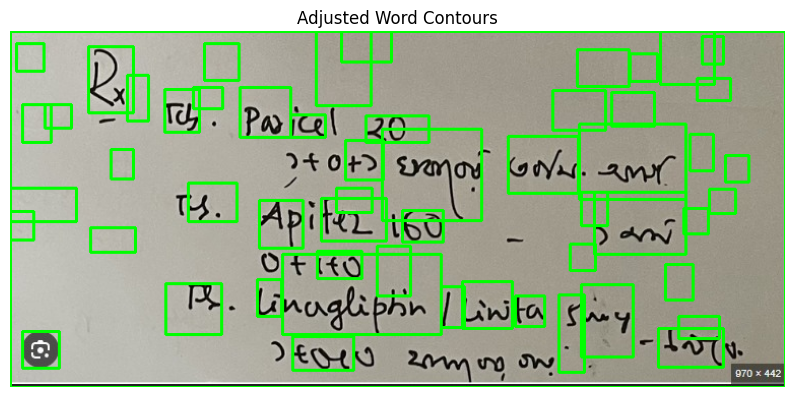

Detected 56 word regions.


In [10]:
import cv2
import matplotlib.pyplot as plt

def get_word_contours_adjusted(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 3)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))  # Larger kernel for closing
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    word_regions = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h
        aspect_ratio = float(w) / h if h > 0 else 0
        if w > 20 and h > 20 and area > 400 and 0.2 < aspect_ratio < 5:  # More aggressive filtering
            word_regions.append((x, y, w, h))

    image_with_boxes = image.copy()
    for x, y, w, h in word_regions:
        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
    plt.title("Adjusted Word Contours")
    plt.axis('off')
    plt.show()

    return word_regions, image

image_path = 'C:/Users/vaibh/Downloads/prescription3.jpg'
word_regions, original_image = get_word_contours_adjusted(image_path)

if word_regions:
    print(f"Detected {len(word_regions)} word regions.")

2025-04-03 20:00:37,146: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


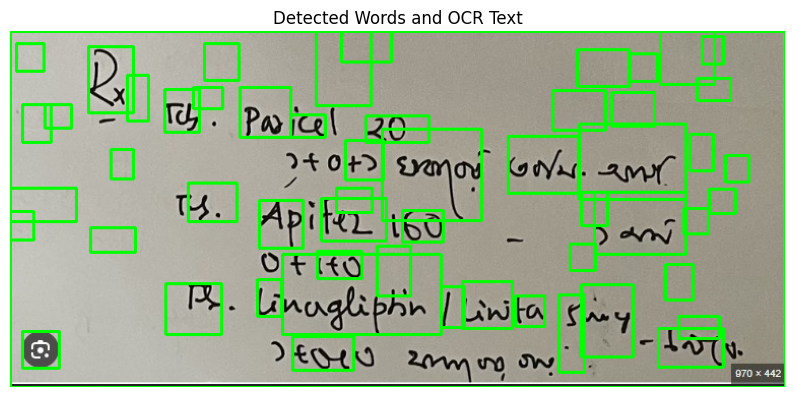

Extracted Text (with spelling correction): eo i ta ln t fo f0 60 ap fr2 a gn fu r 20 ice td pm 2x


In [11]:
import cv2
import easyocr
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

def get_word_contours_adjusted(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 15, 3)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    word_regions = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h
        aspect_ratio = float(w) / h if h > 0 else 0
        if w > 20 and h > 20 and area > 400 and 0.2 < aspect_ratio < 5:
            word_regions.append((x, y, w, h))

    return word_regions, image

def ocr_word_regions(image, word_regions):
    reader = easyocr.Reader(['en'])
    extracted_text = []

    for x, y, w, h in word_regions:
        word_image = image[y:y + h, x:x + w]
        results = reader.readtext(word_image, detail=0)
        if results:
            extracted_text.append(results[0])

    return " ".join(extracted_text)

def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

def process_image_with_contours_ocr(image_path):
    word_regions, original_image = get_word_contours_adjusted(image_path)
    text = ocr_word_regions(original_image, word_regions)
    corrected_text = correct_spelling(text)

    # Visualization
    image_with_boxes = original_image.copy()
    for x, y, w, h in word_regions:
        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
    plt.title("Detected Words and OCR Text")
    plt.axis('off')
    plt.show()

    print("Extracted Text (with spelling correction):", corrected_text)
    return corrected_text

# Example usage
image_path = 'C:/Users/vaibh/Downloads/prescription3.jpg'
extracted_text = process_image_with_contours_ocr(image_path)

2025-04-03 20:21:51,192: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.



Final Extracted Text:

Summary:
Total Results: 0
 - EasyOCR: 0
 - CRNN: 0


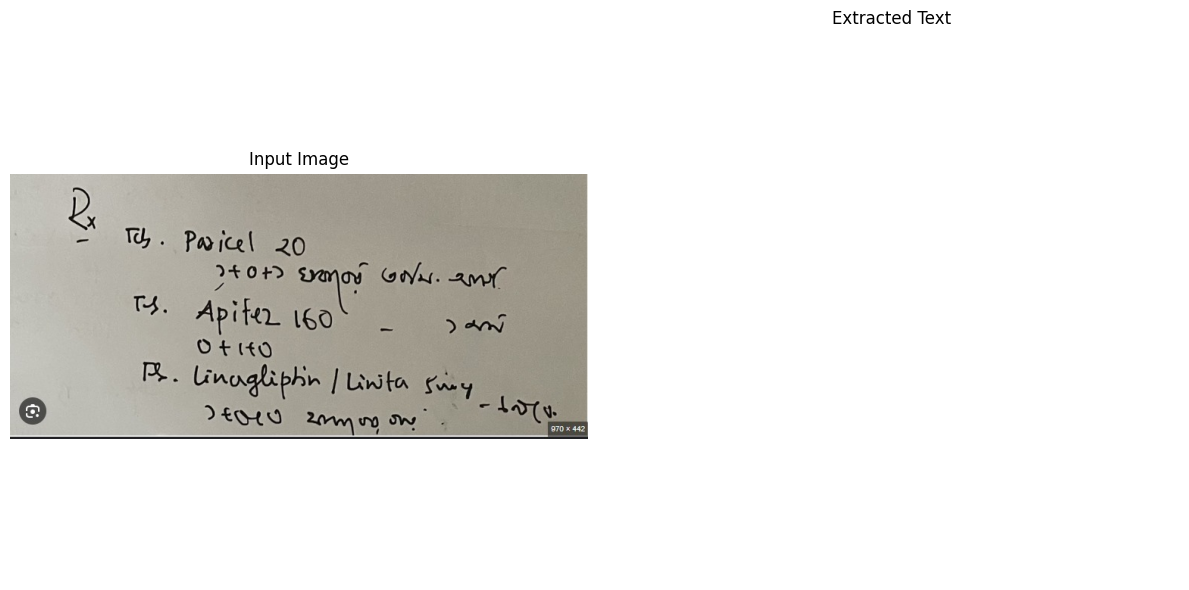

In [20]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//tanmay model_Gem.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (28, 28))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# CRNN prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[int(char)] for char in predicted_class])
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)

    # Preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    # Run EasyOCR with adjusted parameters
    results = reader.readtext(blurred, detail=1, paragraph=True, min_size=5)  # Adjusted parameters

    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for result in results:
        if len(result) == 3:
            bbox, text, confidence = result
            print(f"Detected: {text}, Confidence: {confidence:.4f}")

            # Use CRNN for low-confidence results
            if confidence < confidence_threshold:
                x_min, y_min = map(int, bbox[0])
                x_max, y_max = map(int, bbox[2])
                character_image = image[y_min:y_max, x_min:x_max]

                crnn_text = extract_text_crnn(character_image)
                crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
                print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
                prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
                crnn_count += 1
            else:
                text = correct_spelling(text)  # Apply spelling correction
                prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
                easyocr_count += 1
        else:
            print(f"Warning: Invalid EasyOCR result: {result}")

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/prescription3.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

In [6]:
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
from matplotlib import pyplot as plt

# Load the weights from our repository
model_path = hf_hub_download(local_dir=".",
                             repo_id="armvectores/yolov8n_handwritten_text_detection",
                             filename="best.pt")
model = YOLO(model_path)

# Load test blank
test_blank_path = hf_hub_download(local_dir=".",
                             repo_id="armvectores/yolov8n_handwritten_text_detection",
                             filename="test_blank.png")

# Do the predictions
res = model.predict(source=test_blank_path, project='.',name='detected', exist_ok=True, save=True, show=False, show_labels=False, show_conf=False, conf=0.5, )

plt.figure(figsize=(15,10))
plt.imshow(plt.imread('detected/test_blank.png'))
plt.show()


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\vaibh\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


best.pt:   0%|          | 0.00/6.24M [00:00<?, ?B/s]

WARNING  best.pt appears to require 'dill', which is not in Ultralytics requirements.
AutoInstall will run now for 'dill' but this feature will be removed in the future.
Recommend fixes are to train a new model using the latest 'ultralytics' package or to run a command with an official Ultralytics model, i.e. 'yolo predict model=yolo11n.pt'
requirements: Ultralytics requirement ['dill'] not found, attempting AutoUpdate...
requirements:  AutoUpdate skipped (offline)


ModuleNotFoundError: No module named 'dill'

In [32]:
import easyocr
import numpy as np
import cv2
from tensorflow.keras.models import load_model  # Import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell for spelling correction
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load your trained CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')  # Replace with your model path

# Class mapping
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (32, 128))  # Keep input size 28x28
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[int(char)] for char in predicted_class[0]])  # ✅ FIXED
    return text

# Dynamic thresholding for EasyOCR results
def dynamic_threshold(results, confidence_multiplier=0.5):
    avg_confidence = np.mean([conf for _, _, conf in results])
    return avg_confidence * confidence_multiplier

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Correct spelling using SymSpell
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Hybrid OCR pipeline
def hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    
    # Run EasyOCR
    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        # Use CRNN for low-confidence results
        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            character_image = image[y_min:y_max, x_min:x_max]
            
            crnn_text = extract_text_crnn(character_image)
            crnn_text = correct_spelling(crnn_text)  # Apply spelling correction
            print(f"Low confidence detected. Using CRNN model prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)  # Apply spelling correction
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    # Generate final extracted text
    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])

    # Summary
    summary = f"\nSummary:\nTotal Results: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Test the hybrid OCR pipeline
image_path = 'C:/Users/vaibh/Downloads/d4.jpg'
image, final_text = hybrid_ocr(image_path, confidence_threshold=0.7, min_crnn_confidence=0.5)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.1, 0.5, final_text, fontsize=12, wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()

2025-04-17 17:07:49,028: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Yellew, Confidence: 0.2816
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


KeyError: 78

2025-04-17 17:08:08,207: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Detected: Yellew, Confidence: 0.2816
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Using CRNN prediction: c
Detected: 5s, Confidence: 0.1958
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Using CRNN prediction: unk y
Detected: bxiakt:, Confidence: 0.4059
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Using CRNN prediction: c
Detected: Colouy, Confidence: 0.4777
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Using CRNN prediction: c

Final Extracted Text:
1. Detected Text: c
    Confidence: 0.28 (Low)
    Source: CRNN
----------------------------------------
2. Detected Text: unk y
    Confidence: 0.20 (Low)
    Source: CRNN
----------------------------------------
3. Detected Text: c
    Confidence: 0.41 (Low)
    Source: CRNN
----------------------------------------
4. Detected Text: c
    Confidence: 0.48 (Low)
    Source: CRNN
----------------------------------------
Summary:
Total: 4
 - EasyOCR: 0
 - CRNN: 4


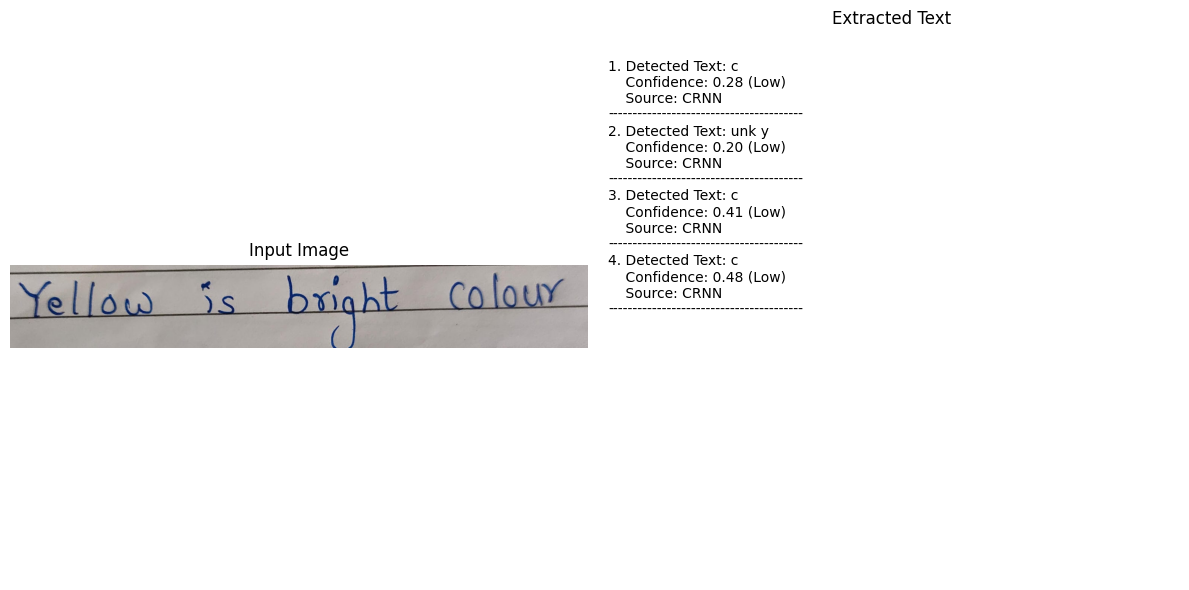

In [33]:
import easyocr
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
from symspellpy import SymSpell, Verbosity

# Initialize SymSpell
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

# Load CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')

# Define parameters
IMAGE_WIDTH = 32
IMAGE_HEIGHT = 128
MAX_LEN = 25  # Use the same max_len used during training

# Load the num_to_char layer from the model
# (Modify if you saved separately; this assumes it was part of training code)
vocab = list("ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789")  # Example; adjust to your training vocab
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, mask_token=None)
num_to_char = tf.keras.layers.StringLookup(vocabulary=char_to_num.get_vocabulary(), mask_token=None, invert=True)

# Preprocess image for CRNN
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (IMAGE_WIDTH, IMAGE_HEIGHT))
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# Decode CRNN prediction using CTC
def decode_crnn_prediction(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0][:, :MAX_LEN]
    
    texts = []
    for res in results:
        res = tf.gather(res, tf.where(tf.math.not_equal(res, -1)))
        text = tf.strings.reduce_join(num_to_char(res)).numpy().decode("utf-8")
        texts.append(text)
    return texts[0] if texts else ""

# Use CRNN for prediction
def extract_text_crnn(image):
    preprocessed_image = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed_image)
    text = decode_crnn_prediction(prediction)
    return text

# Spelling correction
def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# Categorize confidence
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

# Hybrid OCR logic
def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)

    results = reader.readtext(image, detail=1)
    prescription_text = []
    easyocr_count = 0
    crnn_count = 0

    for (bbox, text, confidence) in results:
        print(f"Detected: {text}, Confidence: {confidence:.4f}")

        if confidence < confidence_threshold:
            x_min, y_min = map(int, bbox[0])
            x_max, y_max = map(int, bbox[2])
            char_img = image[y_min:y_max, x_min:x_max]

            crnn_text = extract_text_crnn(char_img)
            crnn_text = correct_spelling(crnn_text)
            print(f"Using CRNN prediction: {crnn_text}")
            prescription_text.append((crnn_text, confidence, 'CRNN', categorize_confidence(confidence)))
            crnn_count += 1
        else:
            text = correct_spelling(text)
            prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
            easyocr_count += 1

    final_text = "\n".join([f"{i+1}. Detected Text: {text}\n    Confidence: {confidence:.2f} ({category})\n    Source: {source}\n{'-'*40}"
                            for i, (text, confidence, source, category) in enumerate(prescription_text)])
    summary = f"\nSummary:\nTotal: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"

    print(f"\nFinal Extracted Text:\n{final_text}{summary}")
    return image, final_text.strip()

# Run on a test image
image_path = 'C:/Users/vaibh/Downloads/d4.jpg'
image, final_text = hybrid_ocr(image_path)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Input Image')
plt.subplot(1, 2, 2)
plt.text(0.01, 0.95, final_text, fontsize=10, va='top', wrap=True)
plt.axis('off')
plt.title('Extracted Text')
plt.tight_layout()
plt.show()


In [34]:
pip install tensorflow opencv-python pillow


Note: you may need to restart the kernel to use updated packages.


In [38]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load CRNN model
crnn_model = load_model('C://Data Set//Trained model//MODEL_NAME.keras')

# Class mapping (A-Z only for now)
class_map = {i: chr(65 + i) for i in range(26)}

# Preprocessing function
def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (32, 128))  # Match CRNN input shape
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

# Prediction function
def predict_crnn(image):
    preprocessed = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map.get(int(char), '') for char in predicted_class[0]])
    return text

# GUI Class
class ImageCropperApp:
    def __init__(self, root):
        self.root = root
        self.root.title("CRNN Image Crop and Predict")
        self.image = None
        self.cv_image = None
        self.start_x = None
        self.start_y = None
        self.rect = None
        self.crop_box = None

        self.canvas = tk.Canvas(root, cursor="cross")
        self.canvas.pack(expand=True, fill=tk.BOTH)

        self.menu = tk.Menu(root)
        self.root.config(menu=self.menu)
        self.menu.add_command(label="Upload Image", command=self.load_image)

        self.label = tk.Label(root, text="Prediction: ", font=("Arial", 14))
        self.label.pack()

        self.canvas.bind("<ButtonPress-1>", self.on_click)
        self.canvas.bind("<B1-Motion>", self.on_drag)
        self.canvas.bind("<ButtonRelease-1>", self.on_release)

    def load_image(self):
        file_path = filedialog.askopenfilename(filetypes=[("Image files", "*.jpg *.png *.jpeg")])
        if not file_path:
            return
        self.cv_image = cv2.imread(file_path)
        self.image = cv2.cvtColor(self.cv_image, cv2.COLOR_BGR2RGB)
        self.pil_image = Image.fromarray(self.image)
        self.tk_image = ImageTk.PhotoImage(self.pil_image)
        self.canvas.create_image(0, 0, image=self.tk_image, anchor="nw")

    def on_click(self, event):
        self.start_x = event.x
        self.start_y = event.y
        self.rect = self.canvas.create_rectangle(self.start_x, self.start_y, self.start_x, self.start_y, outline='red')

    def on_drag(self, event):
        self.canvas.coords(self.rect, self.start_x, self.start_y, event.x, event.y)

    def on_release(self, event):
        end_x, end_y = event.x, event.y
        x1, y1 = min(self.start_x, end_x), min(self.start_y, end_y)
        x2, y2 = max(self.start_x, end_x), max(self.start_y, end_y)
        self.crop_box = (x1, y1, x2, y2)
        self.predict_crop()

    def predict_crop(self):
        if not self.crop_box or not self.cv_image.any():
            messagebox.showwarning("Warning", "No region selected or image not loaded.")
            return

        x1, y1, x2, y2 = self.crop_box

        # Resize coordinates based on displayed image scale
        ratio_w = self.cv_image.shape[1] / self.canvas.winfo_width()
        ratio_h = self.cv_image.shape[0] / self.canvas.winfo_height()

        x1 = int(x1 * ratio_w)
        x2 = int(x2 * ratio_w)
        y1 = int(y1 * ratio_h)
        y2 = int(y2 * ratio_h)

        cropped_image = self.cv_image[y1:y2, x1:x2]
        if cropped_image.size == 0:
            self.label.config(text="Prediction: Invalid crop")
            return

        try:
            prediction = predict_crnn(cropped_image)
            self.label.config(text=f"Prediction: {prediction}")
        except Exception as e:
            self.label.config(text=f"Prediction Error: {str(e)}")

# Run GUI
if __name__ == "__main__":
    root = tk.Tk()
    app = ImageCropperApp(root)
    root.mainloop()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 977ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [49]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import cv2
import numpy as np
import easyocr
from symspellpy import SymSpell, Verbosity
from tensorflow.keras.models import load_model
import os

# ------------------ CRNN Setup ------------------
CRNN_INPUT_SIZE = (32, 128)
class_map = {i: chr(65 + i) for i in range(26)}

try:
    crnn_model = load_model('C://Data Set//Trained model//tanmay model_Gem.keras')
except Exception as e:
    messagebox.showerror("Error", f"Failed to load CRNN model: {e}")
    raise

def preprocess_for_crnn(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, CRNN_INPUT_SIZE)
    normalized = resized.astype('float32') / 255.0
    reshaped = np.expand_dims(normalized, axis=-1)
    return np.expand_dims(reshaped, axis=0)

def extract_text_crnn(image):
    preprocessed = preprocess_for_crnn(image)
    prediction = crnn_model.predict(preprocessed)
    predicted_class = np.argmax(prediction, axis=-1)
    text = ''.join([class_map[int(char)] for char in predicted_class])
    return text

# ------------------ SymSpell Setup ------------------
sym_spell = SymSpell(max_dictionary_edit_distance=2)
sym_spell.load_dictionary("frequency_dictionary_en_82_765.txt", 0, 1)

def correct_spelling(text):
    suggestions = sym_spell.lookup_compound(text, max_edit_distance=2)
    return suggestions[0].term if suggestions else text

# ------------------ Hybrid OCR ------------------
def categorize_confidence(confidence):
    if confidence >= 0.85:
        return 'High'
    elif confidence >= 0.60:
        return 'Medium'
    else:
        return 'Low'

def hybrid_ocr(image_path, confidence_threshold=0.7):
    reader = easyocr.Reader(['en'])
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    blurred = cv2.GaussianBlur(enhanced, (5, 5), 0)

    results = reader.readtext(blurred, detail=1, paragraph=True, min_size=5)
    prescription_text = []
    invalid_results = []
    easyocr_count = 0
    crnn_count = 0

    for result in results:
        if len(result) == 3:
            bbox, text, confidence = result
            if confidence < confidence_threshold:
                x_min, y_min = map(int, bbox[0])
                x_max, y_max = map(int, bbox[2])
                char_img = image[y_min:y_max, x_min:x_max]
                crnn_text = extract_text_crnn(char_img)
                crnn_text = correct_spelling(crnn_text)
                prescription_text.append((crnn_text, confidence, 'CRNN', categorize_confidence(confidence)))
                crnn_count += 1
            else:
                text = correct_spelling(text)
                prescription_text.append((text, confidence, 'EasyOCR', categorize_confidence(confidence)))
                easyocr_count += 1
        else:
            invalid_results.append(str(result))

    final_text = "\n".join([
        f"{i+1}. Text: {text}\n    Confidence: {confidence:.2f} ({cat})\n    Source: {source}\n{'-'*40}"
        for i, (text, confidence, source, cat) in enumerate(prescription_text)
    ])
    summary = f"\nSummary:\nTotal: {easyocr_count + crnn_count}\n - EasyOCR: {easyocr_count}\n - CRNN: {crnn_count}"
    return image, final_text.strip() + summary, invalid_results

# ------------------ GUI Application ------------------
class HybridOCRApp:
    def __init__(self, root):
        self.root = root
        self.root.title("Hybrid OCR with EasyOCR + CRNN + Spell Correction")
        self.cv_image = None
        self.tk_image = None
        self.crop_box = None
        self.start_x = self.start_y = self.rect = None

        self.canvas = tk.Canvas(root, cursor="cross")
        self.canvas.pack(expand=True, fill=tk.BOTH)

        self.label = tk.Label(root, text="Prediction Result", font=("Arial", 14))
        self.label.pack()

        self.result_text = tk.Text(root, height=15, width=80)
        self.result_text.pack(pady=10)

        tk.Button(root, text="Upload Image", command=self.load_image).pack()
        tk.Button(root, text="Run Full Image OCR", command=self.run_full_ocr).pack()

        self.canvas.bind("<ButtonPress-1>", self.on_click)
        self.canvas.bind("<B1-Motion>", self.on_drag)
        self.canvas.bind("<ButtonRelease-1>", self.on_release)

    def load_image(self):
        file_path = filedialog.askopenfilename(filetypes=[("Image files", "*.jpg *.png *.jpeg")])
        if not file_path:
            return
        self.cv_image = cv2.imread(file_path)
        image_rgb = cv2.cvtColor(self.cv_image, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(image_rgb)
        self.tk_image = ImageTk.PhotoImage(pil_image)
        self.canvas.delete("all")
        self.canvas.create_image(0, 0, image=self.tk_image, anchor="nw")
        self.root.update()

    def on_click(self, event):
        self.start_x = event.x
        self.start_y = event.y
        self.rect = self.canvas.create_rectangle(self.start_x, self.start_y, self.start_x, self.start_y, outline='red')

    def on_drag(self, event):
        self.canvas.coords(self.rect, self.start_x, self.start_y, event.x, event.y)

    def on_release(self, event):
        self.crop_box = (min(self.start_x, event.x), min(self.start_y, event.y),
                         max(self.start_x, event.x), max(self.start_y, event.y))
        self.run_crop_ocr()

    def run_crop_ocr(self):
        if not self.crop_box or self.cv_image is None:
            messagebox.showwarning("Warning", "No image or crop box found")
            return

        x1, y1, x2, y2 = self.crop_box
        canvas_w, canvas_h = self.canvas.winfo_width(), self.canvas.winfo_height()
        image_h, image_w = self.cv_image.shape[:2]
        ratio_w = image_w / canvas_w
        ratio_h = image_h / canvas_h

        x1 = int(x1 * ratio_w)
        x2 = int(x2 * ratio_w)
        y1 = int(y1 * ratio_h)
        y2 = int(y2 * ratio_h)

        cropped = self.cv_image[y1:y2, x1:x2]
        if cropped.size == 0:
            self.result_text.delete(1.0, tk.END)
            self.result_text.insert(tk.END, "Invalid crop.")
            return

        temp_path = "temp_crop.png"
        cv2.imwrite(temp_path, cropped)
        _, prediction, invalid = hybrid_ocr(temp_path)
        self.display_result(prediction, invalid)
        os.remove(temp_path)

    def run_full_ocr(self):
        if self.cv_image is None:
            messagebox.showwarning("Warning", "Please upload an image first.")
            return
        temp_path = "full_image_temp.png"
        cv2.imwrite(temp_path, self.cv_image)
        _, prediction, invalid = hybrid_ocr(temp_path)
        self.display_result(prediction, invalid)
        os.remove(temp_path)

    def display_result(self, prediction, invalid_results):
        self.result_text.delete(1.0, tk.END)
        self.result_text.insert(tk.END, prediction)
        if invalid_results:
            self.result_text.insert(tk.END, f"\n\nInvalid EasyOCR Results:\n" + "\n".join(invalid_results))

# ------------------ Launch App ------------------
if __name__ == "__main__":
    root = tk.Tk()
    app = HybridOCRApp(root)
    root.mainloop()

2025-04-17 17:36:20,709: E symspellpy.symspellpy] Dictionary file not found at frequency_dictionary_en_82_765.txt.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.
